In [1]:
# --- Clean & pin a compatible Zarr stack for Colab (Py 3.12) ---
!pip -q uninstall -y zarr numcodecs blosc python-blosc
!pip -q install "zarr==2.17.2" "numcodecs==0.12.1" "xarray>=2024.2.0" \
                "fsspec>=2023.6.0" "gcsfs>=2023.6.0" "intake-esm>=2024.2.10" \
                "cftime" "h5netcdf" "netCDF4" "cartopy"

# Hard restart so compiled extensions (numcodecs.blosc) reload cleanly
import IPython
IPython.display.clear_output(wait=True)
print("Rebooting kernel to finalize installs...")
IPython.get_ipython().kernel.do_shutdown(True)



Rebooting kernel to finalize installs...


{'status': 'ok', 'restart': True}

In [2]:
import xarray as xr, zarr
from numcodecs import blosc as nblosc
print("zarr:", zarr.__version__)
print("numcodecs blosc:", getattr(nblosc, "BLOSC_VERSION_STRING", "OK"))
print("engines:", xr.backends.list_engines())
assert "zarr" in xr.backends.list_engines()

import os, numpy as np, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
import intake

# mount Drive for input/output
from google.colab import drive
drive.mount('/content/drive')

WORKDIR = "/content/drive/MyDrive/climate_work"   # change if needed
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{OUTDIR}/output_maps"
os.makedirs(PLOTDIR, exist_ok=True)

print("WORKDIR:", WORKDIR)
print("OUTDIR :", OUTDIR)
print("PLOTDIR:", PLOTDIR)


zarr: 2.17.2
numcodecs blosc: OK
engines: {'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html, 'h5netcdf': <H5netcdfBackendEntrypoint>
  Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using h5netcdf in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.H5netcdfBackendEntrypoint.html, 'scipy': <ScipyBackendEntrypoint>
  Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html, 'pydap': <PydapBackendEntrypoint>
  Open remote datasets via OPeNDAP using pydap in Xarray
  Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.PydapBackendEntrypoint.html, 'store': <StoreBackendEntrypoint>
  Open AbstractDataStore instances in Xarray
  Learn more at https:/

In [ ]:
!pip -q install "intake-esm>=2024.2.10" "gcsfs>=2023.6.0" "cftime" "h5netcdf" "netCDF4" "cartopy"



In [ ]:
# Open multiple files with chunking to handle large datasets
chunks = {"time": 365}  # tune if you want
ds = xr.open_mfdataset(inputs, combine="by_coords", parallel=True, chunks=chunks)

# Pick a variable (auto-detect, or set varname = "tmax" if you prefer)
varname = find_data_var(ds)
print("Using variable:", varname)
da = ds[varname]

# Kelvin -> °C if needed
units = da.attrs.get("units", "").lower()
if units in ["k", "kelvin"] or (float(da.max()) > 200 and float(da.min()) > 150):
    print("[info] Converting Kelvin to degC.")
    da = da - 273.15
    da.attrs["units"] = "degree_Celsius"

# (Optional) add climatology if your inputs are anomalies.
# If you have one, point clim_path to it; else leave as None and it will skip.
clim_path = None  # e.g., f"{WORKDIR}/TMAX_climatology.nc"
clim_ds = xr.open_dataset(clim_path) if clim_path else None
da = add_climatology_if_needed(da, clim_ds)

# Subset to 1990–2014 (full globe; you can subset lat/lon later for plotting)
ds_sub = subset_1990_2014(da.to_dataset(name=varname))
da_sub = ds_sub[varname]

# Compute percentiles
pct = compute_percentiles(da_sub, q_list=(0.90, 0.98, 0.99))
pct.attrs.update(da_sub.attrs)

# Save to Drive (OUTDIR)
base_name = varname if varname != "temperature" else "tmax"
save_percentiles(pct, OUTDIR, base_name=base_name)

In [ ]:
CANDIDATE_VARS = [
    "tmax", "tasmax", "TMAX", "tx", "TX", "temperature"  # 'temperature' often in Berkeley anomaly files
]

def find_data_var(ds):
    for name in CANDIDATE_VARS:
        if name in ds.data_vars:
            return name
    for name, da in ds.data_vars.items():
        if "time" in da.dims and np.issubdtype(da.dtype, np.floating):
            return name
    raise ValueError("Could not find a Tmax-like variable. Checked: " + ", ".join(CANDIDATE_VARS))

def add_climatology_if_needed(da, clim_ds=None):
    # Heuristic: anomalies tend to sit within ~±25°C
    vmin = float(da.min())
    vmax = float(da.max())
    likely_anomaly = (vmin > -50) and (vmax < 50) and (abs(vmin) < 25 and abs(vmax) < 25)
    if likely_anomaly and clim_ds is not None:
        print("[info] Adding climatology to anomaly field to obtain absolute Tmax.")
        clim_vars = ["climatology", "tmax_climatology", "TMAX_climatology", "tmax_clim", "clim"]
        clim_var = next((v for v in clim_vars if v in clim_ds.data_vars), None)
        if clim_var is None:
            non_coord = [k for k in clim_ds.data_vars]
            clim_var = non_coord[0] if len(non_coord) == 1 else None
        if clim_var is None:
            print("[warn] Could not auto-detect a climatology variable; proceeding without it.")
            return da
        clim = clim_ds[clim_var]
        if "time" in clim.dims and "time" in da.dims:
            clim = clim.sel(time=da.time)
        elif "dayofyear" in clim.dims and "time" in da.dims:
            doy = xr.DataArray(da["time"].dt.dayofyear, dims=("time",), coords={"time": da["time"]})
            clim = clim.sel(dayofyear=doy)
        return da + clim
    return da

def ensure_time(ds):
    if "time" in ds.coords:
        return ds
    if "year" in ds.coords:
        print("[warn] No 'time' coord found; using 'year' to create a pseudo-time.")
        time = xr.cftime_range(start=f"{int(ds.year.min())}-07-01", periods=ds.sizes["year"], freq="AS-JUL")
        return ds.assign_coords(time=("year", time))
    raise ValueError("Dataset lacks a 'time' or 'year' coordinate; cannot filter to 1990–2014.")

def subset_1990_2014(ds):
    ds = ensure_time(ds)
    return ds.sel(time=slice("1990-01-01", "2014-12-31"))

def compute_percentiles(da, q_list=(0.90, 0.98, 0.99)):
    qs = xr.DataArray(list(q_list), dims="quantile", coords={"quantile": list(q_list)})
    pct = da.quantile(q=qs, dim="time", skipna=True, keep_attrs=True)
    return pct

def save_percentiles(pct_da, outdir, base_name="tmax"):
    os.makedirs(outdir, exist_ok=True)
    mapping = {"0.90": "90", "0.98": "98", "0.99": "99"}
    for q_val in pct_da.quantile.values:
        q_str = f"{q_val:.2f}"
        tag = mapping.get(q_str, q_str.replace(".", ""))
        varname = f"{base_name}_{tag}th_percentile"
        out_path = os.path.join(outdir, f"{base_name}_{tag}th_percentile.nc")
        ds_out = xr.Dataset({varname: pct_da.sel(quantile=q_val).drop_vars("quantile", errors="ignore")})
        ds_out[varname].attrs["long_name"] = f"{base_name.upper()} {int(float(tag))}th percentile (1990–2014)"
        if "units" in pct_da.attrs:
            ds_out[varname].attrs["units"] = pct_da.attrs["units"]
        ds_out.to_netcdf(out_path)
        print("[saved]", out_path)


In [ ]:
# EDIT these to wherever your files live in Drive:
base_name = "tmax"  # change if your variable is named differently in the files

percentile_files = {
    "percentile_90": f"{OUTDIR}/{base_name}_90th_percentile.nc",
    "percentile_98": f"{OUTDIR}/{base_name}_98th_percentile.nc",
    "percentile_99": f"{OUTDIR}/{base_name}_99th_percentile.nc",
}

percentile_files


{'percentile_90': '/content/drive/MyDrive/climate_work/historical_output/tmax_90th_percentile.nc',
 'percentile_98': '/content/drive/MyDrive/climate_work/historical_output/tmax_98th_percentile.nc',
 'percentile_99': '/content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc'}

In [ ]:
import intake, xarray as xr

# Open catalog and search
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
cat = col.search(source_id="ACCESS-CM2", experiment_id="historical", table_id="day", variable_id="tasmax")

# Try intake → xarray; fallback to direct open_zarr if needed
try:
    dsets = cat.to_dataset_dict(
        zarr_kwargs={"consolidated": True, "use_cftime": True},
        storage_options={"token": "anon"},
    )
    print(f"Found {len(dsets)} dataset(s) via intake")
    ds_model = list(dsets.values())[0]
except Exception as e:
    print("[warn] intake failed, using direct open_zarr:", e)
    df = cat.df[["member_id","grid_label","zstore"]].drop_duplicates().sort_values(["member_id","grid_label"]).reset_index(drop=True)
    zurl = df.iloc[0]["zstore"]  # choose a specific row if you want a specific member/grid
    ds_model = xr.open_zarr(zurl, consolidated=True, storage_options={"token": "anon"})

# Standardize longitudes and subset 1990–2014
if ds_model["lon"].max() > 180:
    ds_model = ds_model.assign_coords(lon=((ds_model["lon"] + 180) % 360) - 180)
ds_model = ds_model.sortby("lon")

tas = ds_model["tasmax"].sel(time=slice("1990-01-01", "2014-12-31"))

# Convert Kelvin → °C if needed
units = tas.attrs.get("units", "").lower()
if units in ["k", "kelvin"] or (float(tas.max()) > 200 and float(tas.min()) > 150):
    tas = tas - 273.15
    tas.attrs["units"] = "degree_Celsius"

model_mean_mid = tas.mean("time").sel(lat=slice(-60, 60))
print("Model mean:", model_mean_mid.shape, model_mean_mid.attrs.get("units", ""))



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


Found 1 dataset(s) via intake
Model mean: (3, 1, 96, 192) 


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WORKDIR: /content/drive/MyDrive/climate_work
OUTDIR : /content/drive/MyDrive/climate_work/historical_output
PLOTDIR: /content/drive/MyDrive/climate_work/historical_output/output_maps
Berkeley files: {90: '/content/drive/MyDrive/climate_work/historical_output/tmax_90th_percentile.nc', 98: '/content/drive/MyDrive/climate_work/historical_output/tmax_98th_percentile.nc', 99: '/content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc'}

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


[info] Loaded via intake; found 1 dataset(s)

--- Debug 90th ---
Berkeley units: Not specified
Berkeley range: 9.054685828089713 .. 46.780989331007
Model units   : degree_Celsius
Model range   : 2.4924214680989585 .. 47.52928670247396
Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p90_berkeley.png


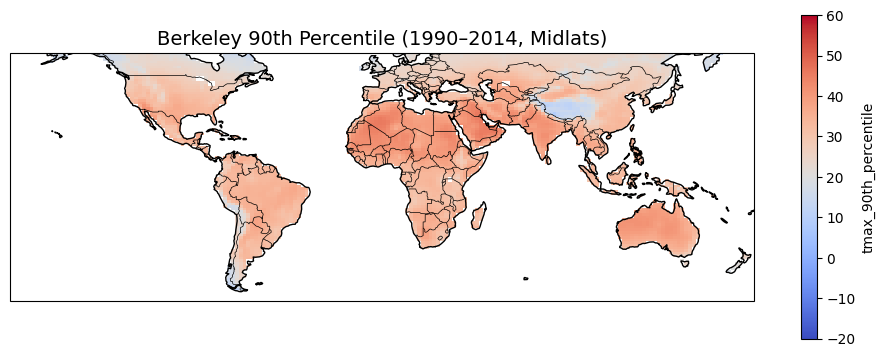

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p90_model.png


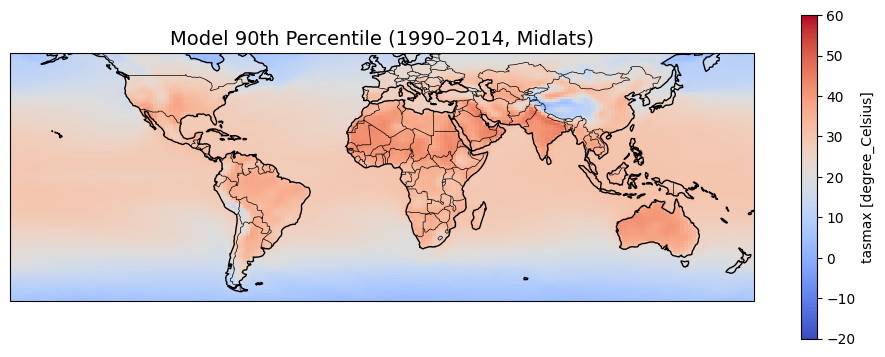

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p90_difference.png


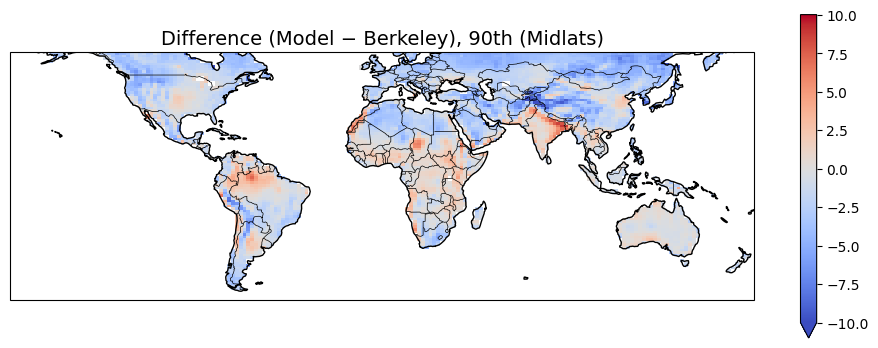


--- Debug 98th ---
Berkeley units: Not specified
Berkeley range: 10.86110736370086 .. 48.73662277340889
Model units   : degree_Celsius
Model range   : 4.2411356608072905 .. 49.60565388997396
Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p98_berkeley.png


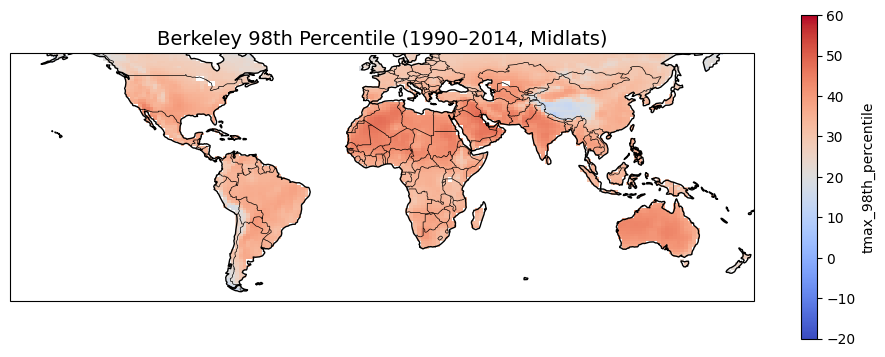

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p98_model.png


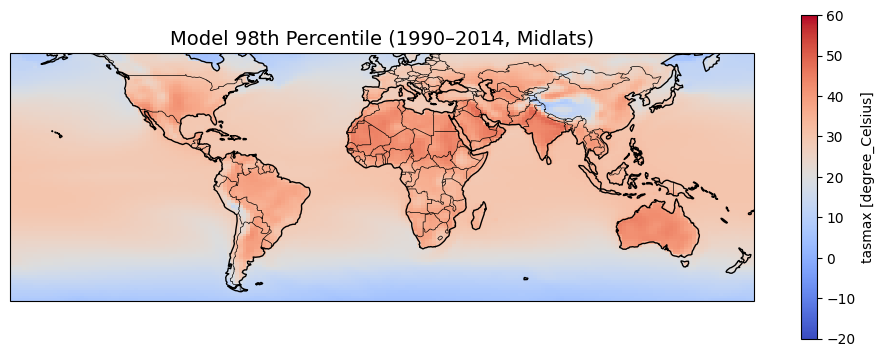

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p98_difference.png


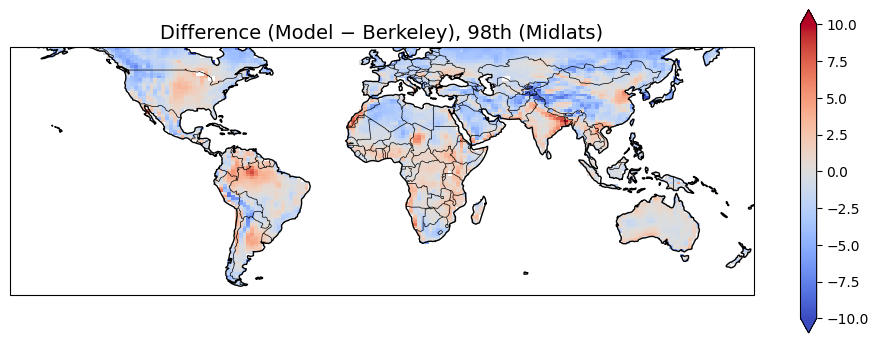


--- Debug 99th ---
Berkeley units: Not specified
Berkeley range: 11.487157442271716 .. 49.29302765011788
Model units   : degree_Celsius
Model range   : 4.772361246744798 .. 50.1795389811198
Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p99_berkeley.png


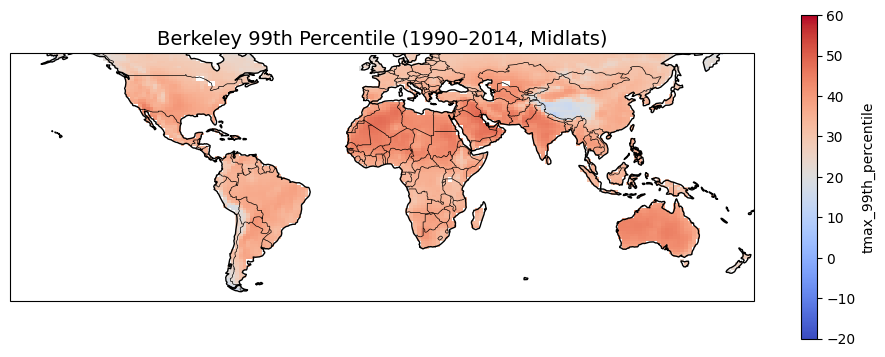

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p99_model.png


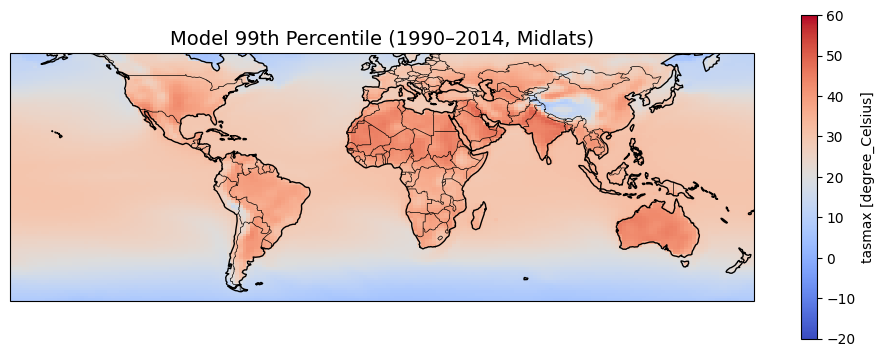

Saved: /content/drive/MyDrive/climate_work/historical_output/output_maps/p99_difference.png


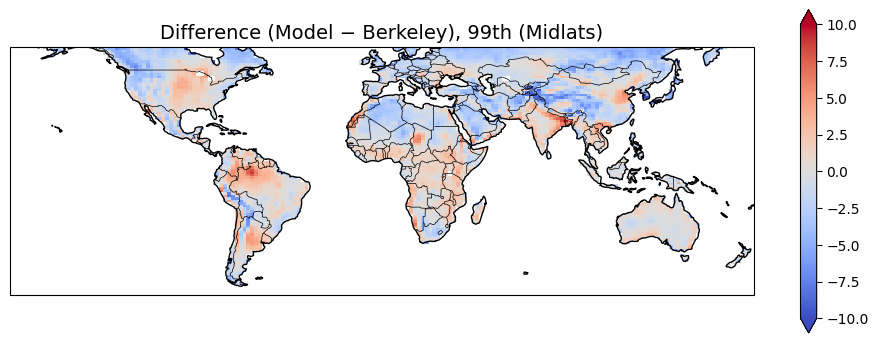


[done] All percentile comparisons saved in: /content/drive/MyDrive/climate_work/historical_output/output_maps


In [ ]:
# ===============================================
# Model (90/98/99) vs Berkeley (90/98/99) percentiles
# ===============================================

# --- Imports & Drive setup ---
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake

from google.colab import drive
drive.mount('/content/drive')

# --- Paths (edit if needed) ---
WORKDIR = "/content/drive/MyDrive/climate_work"
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{OUTDIR}/output_maps"
os.makedirs(PLOTDIR, exist_ok=True)

# Berkeley percentile files (already computed)
base_name = "tmax"  # change if your variable in the files is named differently
percentile_files = {
    90: f"{OUTDIR}/{base_name}_90th_percentile.nc",
    98: f"{OUTDIR}/{base_name}_98th_percentile.nc",
    99: f"{OUTDIR}/{base_name}_99th_percentile.nc",
}

print("WORKDIR:", WORKDIR)
print("OUTDIR :", OUTDIR)
print("PLOTDIR:", PLOTDIR)
print("Berkeley files:", percentile_files)

# --- Pull model tasmax from CMIP6 zarr catalog ---
col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
cat = col.search(
    source_id="ACCESS-CM2",
    experiment_id="historical",
    table_id="day",
    variable_id="tasmax",
    # For reproducibility you can pin these:
    # member_id="r1i1p1f1", grid_label="gn",
)

try:
    dsets = cat.to_dataset_dict(
        zarr_kwargs={"consolidated": True, "use_cftime": True},
        storage_options={"token": "anon"},
    )
    print(f"[info] Loaded via intake; found {len(dsets)} dataset(s)")
    ds_model = list(dsets.values())[0]
except Exception as e:
    print("[warn] intake failed; falling back to direct open_zarr:", e)
    df = cat.df[["member_id","grid_label","zstore"]].drop_duplicates().sort_values(["member_id","grid_label"]).reset_index(drop=True)
    zurl = df.iloc[0]["zstore"]
    ds_model = xr.open_zarr(zurl, consolidated=True, storage_options={"token": "anon"})

# Standardize longitude to [-180, 180] and sort
if ds_model["lon"].max() > 180:
    ds_model = ds_model.assign_coords(lon=((ds_model["lon"] + 180) % 360) - 180)
ds_model = ds_model.sortby("lon")

# --- Subset 1990–2014 and convert Kelvin→°C if needed ---
tas = ds_model["tasmax"].sel(time=slice("1990-01-01", "2014-12-31"))
units = tas.attrs.get("units", "").lower()
if units in ["k", "kelvin"] or (float(tas.max()) > 200 and float(tas.min()) > 150):
    tas = tas - 273.15
    tas.attrs["units"] = "degree_Celsius"

# --- Compute model's percentiles (per grid cell over time) ---
Q_LIST = [0.90, 0.98, 0.99]
qs = xr.DataArray(Q_LIST, dims="quantile", coords={"quantile": Q_LIST})
model_pct_all = tas.quantile(q=qs, dim="time", skipna=True, keep_attrs=True)  # dims: quantile, lat, lon
model_pct_all.attrs.update(tas.attrs)

# --- Helpers: ensure 2D (lat,lon), plotting, debugging ---
def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    """Force a true 2D (lat, lon) field:
       - convert Datasets to DataArrays
       - normalize coord names (latitude/longitude → lat/lon)
       - squeeze singletons
       - average any leftover non-(lat,lon) dims
       - sort latitude ascending
    """
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray):
        da = xr.DataArray(da)

    ren = {}
    if "latitude" in da.dims: ren["latitude"] = "lat"
    if "longitude" in da.dims: ren["longitude"] = "lon"
    if ren:
        da = da.rename(ren)

    da = da.squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat", "lon")]
    if extra:
        da = da.mean(dim=extra, keep_attrs=True)

    if "lat" in da.dims and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")

    return da

def plot_map(data, title, vmin=None, vmax=None, save_path=None):
    da = to_latlon_2d(data).astype("float64")
    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -60, 60], crs=ccrs.PlateCarree())
    da.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="coolwarm",
        vmin=vmin, vmax=vmax,
        add_colorbar=True, cbar_kwargs={"shrink": 0.7},
    )
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title, fontsize=14)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved:", save_path)
    plt.show(); plt.close()

def debug_units_and_ranges(berkeley_data, model_data, tag):
    bd = to_latlon_2d(berkeley_data)
    md = to_latlon_2d(model_data)
    print(f"\n--- Debug {tag} ---")
    print(f"Berkeley units: {bd.attrs.get('units', 'Not specified')}")
    print(f"Berkeley range: {float(bd.min())} .. {float(bd.max())}")
    print(f"Model units   : {md.attrs.get('units', 'Not specified')}")
    print(f"Model range   : {float(md.min())} .. {float(md.max())}")

# --- Loop over 90/98/99 percentiles ---
for q in [90, 98, 99]:
    qf = q / 100.0

    # Model percentile (2D), midlats
    model_q = model_pct_all.sel(quantile=qf).drop_vars("quantile", errors="ignore")
    model_q_mid = model_q.sel(lat=slice(-60, 60))
    model2 = to_latlon_2d(model_q_mid)

    # Load Berkeley percentile file
    bpath = percentile_files[q]
    berkeley_ds = xr.open_dataset(bpath)

    # Variable name inside the file (fallback to sole var if needed)
    berkeley_var = f"{base_name}_{q}th_percentile"
    if berkeley_var not in berkeley_ds:
        candidates = [v for v in berkeley_ds.data_vars]
        if len(candidates) == 1:
            berkeley_var = candidates[0]
            print(f"[info] Using sole variable in Berkeley file ({q}th): {berkeley_var}")
        else:
            raise ValueError(f"Variable {berkeley_var} not in {bpath}. Vars: {list(berkeley_ds.data_vars)}")

    berkeley = berkeley_ds[berkeley_var]
    if "latitude" in berkeley.dims or "longitude" in berkeley.dims:
        berkeley = berkeley.rename({"latitude": "lat", "longitude": "lon"})

    # Midlats and regrid to the model grid
    berkeley_mid = berkeley.sel(lat=slice(-60, 60))
    berkeley_rg  = berkeley_mid.interp(lat=model2["lat"], lon=model2["lon"], method="linear")
    berkeley2 = to_latlon_2d(berkeley_rg)

    # Debug printouts
    debug_units_and_ranges(berkeley2, model2, f"{q}th")

    # Difference (Model - Berkeley)
    diff = model2 - berkeley2

    # Plots
    plot_map(berkeley2, f"Berkeley {q}th Percentile (1990–2014, Midlats)",
             vmin=-20, vmax=60, save_path=f"{PLOTDIR}/p{q}_berkeley.png")
    plot_map(model2, f"Model {q}th Percentile (1990–2014, Midlats)",
             vmin=-20, vmax=60, save_path=f"{PLOTDIR}/p{q}_model.png")
    plot_map(diff, f"Difference (Model − Berkeley), {q}th (Midlats)",
             vmin=-10, vmax=10, save_path=f"{PLOTDIR}/p{q}_difference.png")

print("\n[done] All percentile comparisons saved in:", PLOTDIR)


In [ ]:
# ============================================================
# CMIP6 tasmax (day, historical 1990–2014) — 99th percentile
# Compare model p99 vs Berkeley p99
# Figures + metrics (Bias, spatial R², centered RMSE) over 45S–45N
# ============================================================

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake

# ---------------- Paths ----------------
# If using Colab, mount Drive (safe to run even if already mounted)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORKDIR = "/content/drive/MyDrive/climate_work" if IN_COLAB else "./climate_work"
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{OUTDIR}/output_maps"
os.makedirs(PLOTDIR, exist_ok=True)

# Berkeley 99th percentile file (absolute °C)
BERKELEY_P99_PATH = f"{OUTDIR}/tmax_99th_percentile.nc"
BERKELEY_VAR_NAME = "tmax_99th_percentile"  # code will fallback to sole var if needed

# Output dir for figures + metrics
OUTPUT_DIR = f"{WORKDIR}/output_figures_cmip6_p99"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("WORKDIR:", WORKDIR)
print("OUTDIR :", OUTDIR)
print("PLOTDIR:", PLOTDIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("BERKELEY_P99_PATH:", BERKELEY_P99_PATH)

# ---------------- Models ----------------
ALLOWED = sorted({
    "ACCESS-CM2","ACCESS-ESM1-5","AWI-CM-1-1-MR","CAMS-CSM1-0","CMCC-CM2-SR5","CMCC-ESM2",
    "CNRM-CM6-1","CNRM-CM6-1-HR","CNRM-ESM2-1","CanESM5","EC-Earth3","EC-Earth3-CC",
    "EC-Earth3-Veg","EC-Earth3-Veg-LR","GFDL-CM4","GFDL-ESM4","HadGEM3-GC31-LL","IITM-ESM",
    "INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL"
})

# Throttle while testing (None = all)
MAX_MODELS  = None          # e.g., 5
REMAKE_FIGS = True          # set False to skip PNGs

# ---------------- Config ----------------
PANGEOCAT = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
Q99 = 0.99
LAT_MIN, LAT_MAX = -45, 45       # metrics region
MID_LAT_MIN, MID_LAT_MAX = -60, 60  # plotting region

# ---------------- Helpers ----------------
def normalize_latlon(obj):
    """Ensure coords named lat/lon; convert 0–360→−180–180; sort by lon."""
    if "latitude" in obj.coords: obj = obj.rename({"latitude":"lat"})
    if "longitude" in obj.coords: obj = obj.rename({"longitude":"lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords:
        obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    """Force a true 2D (lat,lon) DataArray; average any extra dims; sort lat ascending."""
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray):
        da = xr.DataArray(da)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra:
        da = da.mean(dim=extra, keep_attrs=True)
    if "lat" in da.dims and da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def plot_single_map(ax, da2d, title, vmin=None, vmax=None):
    im = da2d.plot.pcolormesh(
        ax=ax, transform=ccrs.PlateCarree(), cmap="coolwarm",
        vmin=vmin, vmax=vmax, add_colorbar=False
    )
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title, fontsize=12)
    return im

def generate_figure_three_panel(model_da, regridded_da, berkeley_native, out_png):
    """3 columns: Model p99, Berkeley (regridded), Berkeley (native)."""
    model_da = to_latlon_2d(model_da)
    regridded_da = to_latlon_2d(regridded_da)
    berkeley_native = to_latlon_2d(berkeley_native)

    fig, axs = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": ccrs.PlateCarree()})
    for ax in axs:
        ax.set_extent([-180, 180, MID_LAT_MIN, MID_LAT_MAX], crs=ccrs.PlateCarree())

    ims = [
        plot_single_map(axs[0], model_da,        "Model 99th percentile (1990–2014)", vmin=-20, vmax=60),
        plot_single_map(axs[1], regridded_da,    "Berkeley (regridded to model)",      vmin=-20, vmax=60),
        plot_single_map(axs[2], berkeley_native, "Berkeley (native grid)",              vmin=-20, vmax=60),
    ]
    for ax, im in zip(axs, ims):
        cbar = plt.colorbar(im, ax=ax, fraction=0.024, pad=0.02)
        cbar.set_label("Temperature (°C)")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)

def calc_spatial_r2(model_da, obs_da):
    """Spatial Pearson R² across grid cells (means removed internally)."""
    m = model_da.values.ravel()
    o = obs_da.values.ravel()
    mask = ~np.isnan(m) & ~np.isnan(o)
    if not np.any(mask): return np.nan
    m = m[mask]; o = o[mask]
    mm = m - m.mean(); oo = o - o.mean()
    denom = np.sqrt((mm**2).sum() * (oo**2).sum())
    if denom == 0: return np.nan
    r = (mm * oo).sum() / denom
    return float(r**2)

def calc_metrics_centered_rmse(model_da, obs_da):
    """
    Spatial metrics on a common grid:
      - rmse: centered RMSE (bias removed first)
      - bias: mean(model - obs)
      - r2  : spatial Pearson R^2 across grid cells
    """
    model_da = to_latlon_2d(model_da)
    obs_da   = to_latlon_2d(obs_da)
    assert model_da.shape == obs_da.shape, "Model and obs must be on the same grid."
    diff  = model_da - obs_da
    bias  = float(diff.mean().values)
    rmse  = float(((diff - diff.mean())**2).mean().values**0.5)  # centered RMSE
    r2    = calc_spatial_r2(model_da, obs_da)
    return rmse, bias, r2

def open_model_p99_from_zarr(source_id):
    """Open tasmax for one model, subset 1990–2014, convert °C, compute 99th percentile."""
    col = intake.open_esm_datastore(PANGEOCAT)
    # For reproducibility, you may pin member_id="r1i1p1f1", grid_label="gn"
    cat = col.search(source_id=source_id, experiment_id="historical", table_id="day", variable_id="tasmax")
    if len(cat.df) == 0:
        raise RuntimeError(f"No historical/day tasmax for {source_id} in Pangeo.")

    try:
        dsets = cat.to_dataset_dict(
            zarr_kwargs={"consolidated": True, "use_cftime": True},
            storage_options={"token": "anon"},
        )
        ds = list(dsets.values())[0]
    except Exception:
        df = cat.df[["member_id","grid_label","zstore"]].drop_duplicates().reset_index(drop=True)
        zurl = df.iloc[0]["zstore"]
        ds = xr.open_zarr(zurl, consolidated=True, storage_options={"token":"anon"})

    ds = normalize_latlon(ds)
    tas = ds["tasmax"].sel(time=slice("1990-01-01","2014-12-31"))

    # Kelvin -> °C if needed
    units = tas.attrs.get("units","").lower()
    if units in ["k","kelvin"] or (float(tas.max())>200 and float(tas.min())>150):
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"

    model_p99 = tas.quantile(q=Q99, dim="time", skipna=True, keep_attrs=True)  # (lat, lon)
    model_p99.attrs.update(tas.attrs)
    return model_p99

def load_berkeley_p99(path, var_expected=BERKELEY_VAR_NAME):
    ds = xr.open_dataset(path)
    if var_expected not in ds:
        vars_in = list(ds.data_vars)
        if len(vars_in) == 1:
            var_expected = vars_in[0]
            print(f"[info] Using sole variable in {os.path.basename(path)}: {var_expected}")
        else:
            raise KeyError(f"{var_expected} not found in {path}. Vars: {vars_in}")
    return normalize_latlon(ds[var_expected])

# ---------------- Main ----------------
# Load Berkeley p99 once
berkeley_native_full = load_berkeley_p99(BERKELEY_P99_PATH, BERKELEY_VAR_NAME)

metrics = []
models_to_run = ALLOWED[:MAX_MODELS] if isinstance(MAX_MODELS, int) else ALLOWED

for source_id in models_to_run:
    print("\n==============================")
    print("Processing model:", source_id)
    print("==============================")

    # 1) Model p99 (2D)
    try:
        model_p99 = open_model_p99_from_zarr(source_id)
    except Exception as e:
        print(f"[skip] {source_id}: {e}")
        continue

    # 2) Midlats and regrid Berkeley to model grid
    model_p99_mid = to_latlon_2d(model_p99).sel(lat=slice(MID_LAT_MIN, MID_LAT_MAX))
    berkeley_mid  = to_latlon_2d(berkeley_native_full).sel(lat=slice(MID_LAT_MIN, MID_LAT_MAX))
    berkeley_rg   = berkeley_mid.interp(lat=model_p99_mid["lat"], lon=model_p99_mid["lon"], method="linear")

    # 3) (Optional) Figure
    if REMAKE_FIGS:
        fig_path = os.path.join(OUTPUT_DIR, f"{source_id}_p99_global.png")
        generate_figure_three_panel(model_p99_mid, berkeley_rg, berkeley_native_full, fig_path)

    # 4) Metrics over 45S–45N (centered RMSE, Bias, R²)
    model_lims = model_p99_mid.sel(lat=slice(LAT_MIN, LAT_MAX))
    obs_lims   = berkeley_rg.sel(lat=slice(LAT_MIN, LAT_MAX))
    rmse, bias, r2 = calc_metrics_centered_rmse(model_lims, obs_lims)

    metrics.append({
        "model": source_id,
        "percentile": 99,
        "rmse": rmse,   # centered RMSE
        "bias": bias,
        "r2": r2,
    })
    print(f"[metrics] {source_id} p99 | cRMSE={rmse:.3f}  Bias={bias:.3f}  R²={r2:.3f}")

# 5) Save metrics CSV
csv_path = os.path.join(OUTPUT_DIR, "cmip6_model_metrics_1990_2014_p99_centeredRMSE.csv")
pd.DataFrame(metrics).to_csv(csv_path, index=False)
print("\nSaved metrics CSV:", csv_path)
print("Done.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
WORKDIR: /content/drive/MyDrive/climate_work
OUTDIR : /content/drive/MyDrive/climate_work/historical_output
PLOTDIR: /content/drive/MyDrive/climate_work/historical_output/output_maps
OUTPUT_DIR: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99
BERKELEY_P99_PATH: /content/drive/MyDrive/climate_work/historical_output/tmax_99th_percentile.nc

Processing model: ACCESS-CM2

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/ACCESS-CM2_p99_global.png
[metrics] ACCESS-CM2 p99 | cRMSE=2.407  Bias=-0.131  R²=0.855

Processing model: ACCESS-ESM1-5

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/ACCESS-ESM1-5_p99_global.png
[metrics] ACCESS-ESM1-5 p99 | cRMSE=3.611  Bias=1.413  R²=0.688

Processing model: AWI-CM-1-1-MR

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/AWI-CM-1-1-MR_p99_global.png
[metrics] AWI-CM-1-1-MR p99 | cRMSE=2.555  Bias=0.615  R²=0.852

Processing model: CAMS-CSM1-0

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


...

Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/IPSL-CM6A-LR_p99_global.png
[metrics] IPSL-CM6A-LR p99 | cRMSE=2.764  Bias=-2.899  R²=0.845

Processing model: NorESM2-LM

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/usr/local/lib/python3.12/dist-packages/intake_esm/source.py:298: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  self._ds = xr.combine_by_coords(


Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/NorESM2-LM_p99_global.png
[metrics] NorESM2-LM p99 | cRMSE=2.501  Bias=0.597  R²=0.807

Processing model: NorESM2-MM

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/NorESM2-MM_p99_global.png
[metrics] NorESM2-MM p99 | cRMSE=2.296  Bias=0.356  R²=0.840

Processing model: TaiESM1

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/TaiESM1_p99_global.png
[metrics] TaiESM1 p99 | cRMSE=2.324  Bias=-6.364  R²=0.871

Processing model: UKESM1-0-LL
[skip] UKESM1-0-LL: No historical/day tasmax for UKESM1-0-LL in Pangeo.

Saved metrics CSV: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/cmip6_model_metrics_1990_2014_p99_centeredRMSE.csv
Done.



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


[TaiESM1 diagnostics] cRMSE=2.324  Bias=-6.364  R²=0.871 (45S–45N)


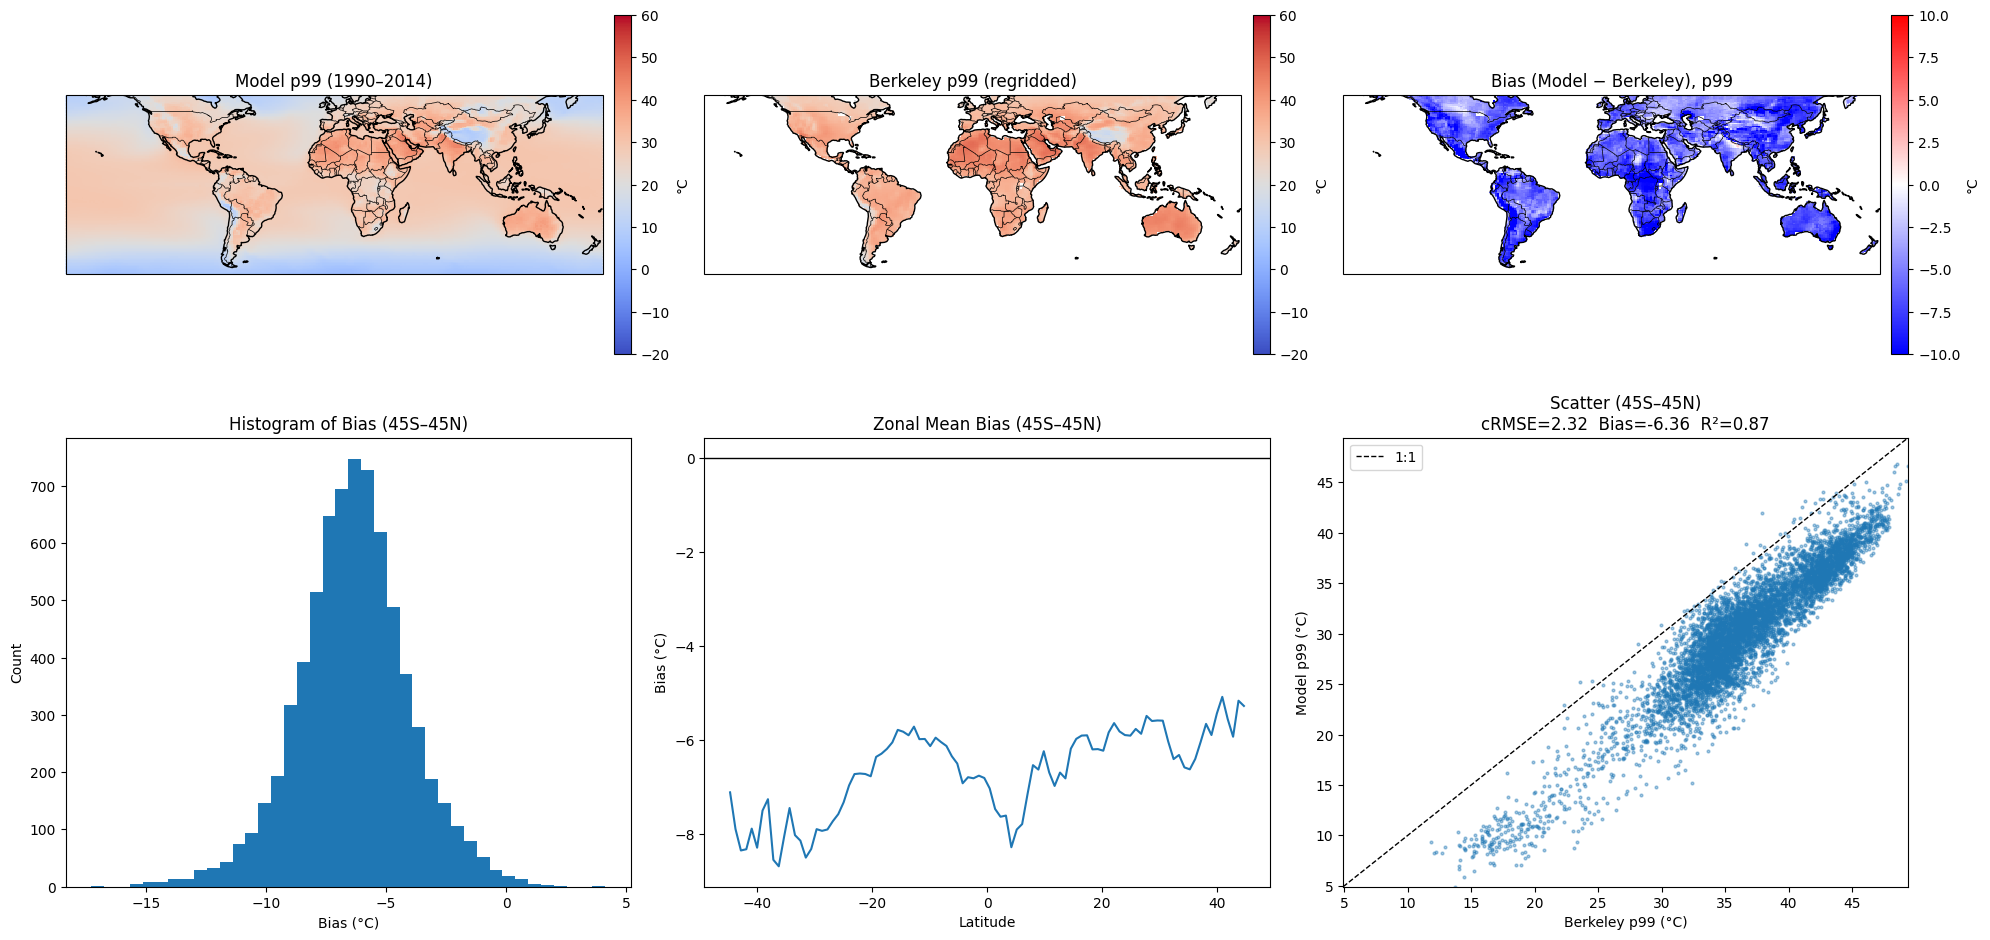

Saved diagnostics: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/TaiESM1_p99_diagnostics.png


In [ ]:
# ===========================
# TaiESM1 p99 diagnostics
# ===========================
import os, numpy as np, xarray as xr, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

# ---- Pick model and paths ----
MODEL_ID   = "TaiESM1"
MID_MIN, MID_MAX = -60, 60      # map extent
LAT_MIN, LAT_MAX = -45, 45      # metrics region
OUTDIR_FIG = OUTPUT_DIR if "OUTPUT_DIR" in globals() else "output_figures_cmip6_p99"
os.makedirs(OUTDIR_FIG, exist_ok=True)

# ---- Minimal fallbacks for helpers (use your existing ones if present) ----
def _normalize_latlon(obj):
    if "latitude" in obj.coords: obj = obj.rename({"latitude":"lat"})
    if "longitude" in obj.coords: obj = obj.rename({"longitude":"lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords: obj = obj.sortby("lon")
    return obj

def _to_latlon_2d(da):
    if isinstance(da, xr.Dataset):
        da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray):
        da = xr.DataArray(da)
    da = _normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra: da = da.mean(dim=extra, keep_attrs=True)
    if "lat" in da.dims and da.lat.size>1 and float(da.lat[0])>float(da.lat[-1]):
        da = da.sortby("lat")
    return da

def _calc_spatial_r2(m, o):
    mv = m.values.ravel(); ov = o.values.ravel()
    mask = ~np.isnan(mv) & ~np.isnan(ov)
    if not np.any(mask): return np.nan
    mv = mv[mask]; ov = ov[mask]
    mm = mv - mv.mean(); oo = ov - ov.mean()
    denom = np.sqrt((mm**2).sum() * (oo**2).sum())
    if denom == 0: return np.nan
    r = (mm*oo).sum()/denom
    return float(r**2)

def _metrics_centered(m, o):
    """Centered RMSE (bias-removed), Bias, spatial R^2."""
    m = _to_latlon_2d(m); o = _to_latlon_2d(o)
    assert m.shape == o.shape
    diff = m - o
    bias = float(diff.mean().values)
    crmse = float(((diff - diff.mean())**2).mean().values**0.5)
    r2 = _calc_spatial_r2(m, o)
    return crmse, bias, r2

def _plot_map(ax, da, title, vmin=None, vmax=None, cmap="coolwarm"):
    im = da.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap,
                            vmin=vmin, vmax=vmax, add_colorbar=False)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent([-180, 180, MID_MIN, MID_MAX], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    return im

# ---- Acquire model p99 and Berkeley p99 (reuse your loaders if available) ----
if "open_model_p99_from_zarr" in globals():
    model_p99 = open_model_p99_from_zarr(MODEL_ID)
else:
    # minimal inline loader via intake
    import intake
    PANGEOCAT = "https://storage.googleapis.com/cmip6/pangeo-cmip6.json"
    Q99 = 0.99
    col = intake.open_esm_datastore(PANGEOCAT)
    cat = col.search(source_id=MODEL_ID, experiment_id="historical", table_id="day", variable_id="tasmax")
    dsets = cat.to_dataset_dict(zarr_kwargs={"consolidated": True, "use_cftime": True},
                                storage_options={"token": "anon"})
    ds = list(dsets.values())[0]
    ds = _normalize_latlon(ds)
    tas = ds["tasmax"].sel(time=slice("1990-01-01","2014-12-31"))
    units = tas.attrs.get("units","").lower()
    if units in ["k","kelvin"] or (float(tas.max())>200 and float(tas.min())>150):
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"
    model_p99 = tas.quantile(q=Q99, dim="time", skipna=True, keep_attrs=True)

# Load Berkeley p99
if "berkeley_native_full" in globals():
    berkeley_native = berkeley_native_full
else:
    BERKELEY_P99_PATH = f"{OUTDIR}/tmax_99th_percentile.nc" if "OUTDIR" in globals() else "tmax_99th_percentile.nc"
    dsb = xr.open_dataset(BERKELEY_P99_PATH)
    var = "tmax_99th_percentile" if "tmax_99th_percentile" in dsb else list(dsb.data_vars)[0]
    berkeley_native = _normalize_latlon(dsb[var])

# ---- Prep midlats, regrid, and metrics region ----
model_mid    = _to_latlon_2d(model_p99).sel(lat=slice(MID_MIN, MID_MAX))
berkeley_mid = _to_latlon_2d(berkeley_native).sel(lat=slice(MID_MIN, MID_MAX))
berkeley_rg  = berkeley_mid.interp(lat=model_mid["lat"], lon=model_mid["lon"], method="linear")
bias_map     = model_mid - berkeley_rg

model_lims = model_mid.sel(lat=slice(LAT_MIN, LAT_MAX))
obs_lims   = berkeley_rg.sel(lat=slice(LAT_MIN, LAT_MAX))
crmse, bias, r2 = _metrics_centered(model_lims, obs_lims)
print(f"[TaiESM1 diagnostics] cRMSE={crmse:.3f}  Bias={bias:.3f}  R²={r2:.3f} (45S–45N)")

# ---- Figure: 2 rows x 3 cols (3 maps + 3 diagnostics) ----
fig = plt.figure(figsize=(20, 10))

# Maps
proj = ccrs.PlateCarree()
ax1 = plt.subplot(2,3,1, projection=proj)
ax2 = plt.subplot(2,3,2, projection=proj)
ax3 = plt.subplot(2,3,3, projection=proj)

im1 = _plot_map(ax1, model_mid,   "Model p99 (1990–2014)", vmin=-20, vmax=60)
im2 = _plot_map(ax2, berkeley_rg, "Berkeley p99 (regridded)", vmin=-20, vmax=60)
im3 = _plot_map(ax3, bias_map,    "Bias (Model − Berkeley), p99", vmin=-10, vmax=10, cmap="bwr")

for ax, im in zip([ax1,ax2,ax3],[im1,im2,im3]):
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("°C")

# Diagnostics: histogram, zonal mean, scatter (45S–45N)
ax4 = plt.subplot(2,3,4)
d = (model_lims - obs_lims).values.ravel()
d = d[~np.isnan(d)]
ax4.hist(d, bins=40)
ax4.set_title("Histogram of Bias (45S–45N)")
ax4.set_xlabel("Bias (°C)"); ax4.set_ylabel("Count")

ax5 = plt.subplot(2,3,5)
# Zonal mean bias on common grid:
zonal_bias = (model_lims - obs_lims).mean(dim="lon")
ax5.plot(zonal_bias["lat"], zonal_bias)
ax5.axhline(0, lw=1, color="k")
ax5.set_title("Zonal Mean Bias (45S–45N)")
ax5.set_xlabel("Latitude"); ax5.set_ylabel("Bias (°C)")

ax6 = plt.subplot(2,3,6)
mvals = model_lims.values.ravel()
ovals = obs_lims.values.ravel()
mask = ~np.isnan(mvals) & ~np.isnan(ovals)
mvals = mvals[mask]; ovals = ovals[mask]
ax6.scatter(ovals, mvals, s=4, alpha=0.4)
mn = np.nanmin([mvals.min(), ovals.min()])
mx = np.nanmax([mvals.max(), ovals.max()])
ax6.plot([mn, mx], [mn, mx], 'k--', lw=1, label="1:1")
ax6.set_xlim(mn, mx); ax6.set_ylim(mn, mx)
ax6.set_xlabel("Berkeley p99 (°C)"); ax6.set_ylabel("Model p99 (°C)")
ax6.set_title(f"Scatter (45S–45N)\ncRMSE={crmse:.2f}  Bias={bias:.2f}  R²={r2:.2f}")
ax6.legend(loc="upper left")

plt.tight_layout()
out_png = os.path.join(OUTDIR_FIG, f"{MODEL_ID}_p99_diagnostics.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print("Saved diagnostics:", out_png)



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


{'GFDL-ESM4 >40C (global)': 4.37, 'Berkeley >40C (global)': 3.72, 'GFDL-ESM4 >40C (45S–45N)': 8.46, 'Berkeley >40C (45S–45N)': 7.41} % of grid cells


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


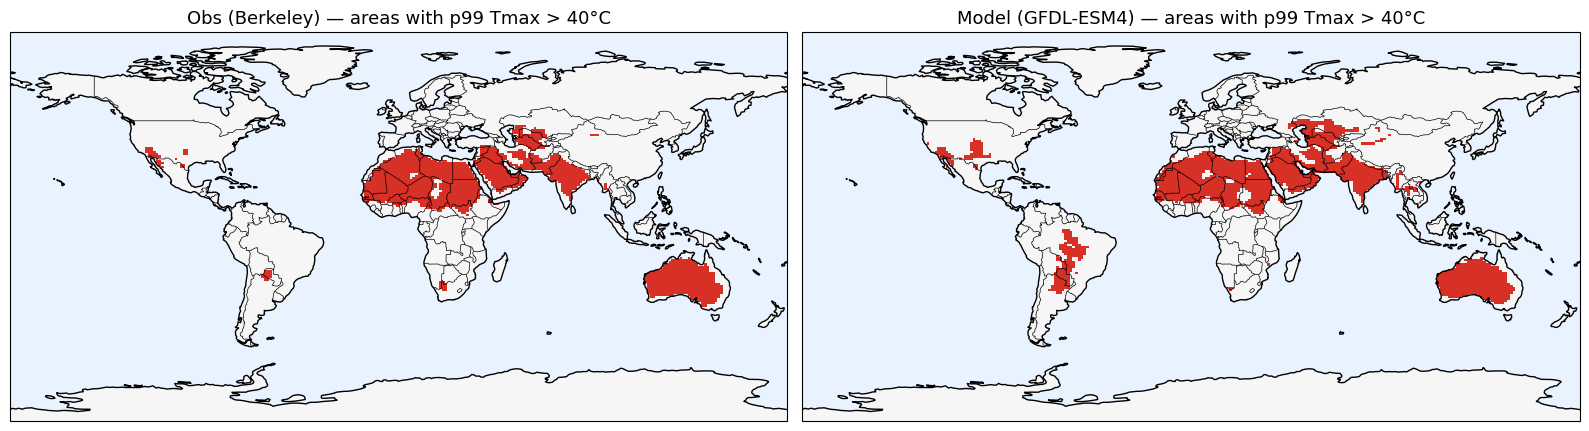

Saved: /content/drive/MyDrive/climate_work/output_figures_cmip6_p99/where_over40C_p99_Berkeley_vs_GFDL-ESM4.png


In [ ]:
# ==============================================
# "Where are max temps > 40°C?" (p99 exceedance)
# Obs: Berkeley; Model: GFDL-ESM4
# ==============================================

import os, numpy as np, xarray as xr, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature
import intake
from matplotlib.colors import ListedColormap

# --- Paths (edit if needed) ---
WORKDIR = "/content/drive/MyDrive/climate_work"
OUTDIR  = f"{WORKDIR}/historical_output"
PLOTDIR = f"{WORKDIR}/output_figures_cmip6_p99"
os.makedirs(PLOTDIR, exist_ok=True)

BERKELEY_P99_PATH = f"{OUTDIR}/tmax_99th_percentile.nc"
BERKELEY_VAR_NAME = "tmax_99th_percentile"  # will auto-fallback to sole var if different

# --- Helpers ---
def normalize_latlon(obj):
    if "latitude" in obj.coords: obj = obj.rename({"latitude":"lat"})
    if "longitude" in obj.coords: obj = obj.rename({"longitude":"lon"})
    if "lon" in obj.coords and float(obj["lon"].max()) > 180:
        obj = obj.assign_coords(lon=((obj["lon"] + 180) % 360) - 180)
    if "lon" in obj.coords: obj = obj.sortby("lon")
    return obj

def to_latlon_2d(da: xr.DataArray) -> xr.DataArray:
    if isinstance(da, xr.Dataset): da = da.to_array().squeeze(drop=True)
    elif not isinstance(da, xr.DataArray): da = xr.DataArray(da)
    da = normalize_latlon(da).squeeze(drop=True)
    extra = [d for d in da.dims if d not in ("lat","lon")]
    if extra: da = da.mean(dim=extra, keep_attrs=True)
    if "lat" in da.dims and da.lat.size>1 and float(da.lat[0])>float(da.lat[-1]): da = da.sortby("lat")
    return da

def open_model_p99_from_zarr(source_id, cat_url="https://storage.googleapis.com/cmip6/pangeo-cmip6.json"):
    col = intake.open_esm_datastore(cat_url)
    cat = col.search(source_id=source_id, experiment_id="historical", table_id="day", variable_id="tasmax")
    dsets = cat.to_dataset_dict(zarr_kwargs={"consolidated": True, "use_cftime": True},
                                storage_options={"token": "anon"})
    ds = list(dsets.values())[0]
    ds = normalize_latlon(ds)
    tas = ds["tasmax"].sel(time=slice("1990-01-01", "2014-12-31"))
    units = tas.attrs.get("units","").lower()
    if units in ["k","kelvin"] or (float(tas.max())>200 and float(tas.min())>150):
        tas = tas - 273.15
        tas.attrs["units"] = "degree_Celsius"
    p99 = tas.quantile(q=0.99, dim="time", skipna=True, keep_attrs=True)
    p99.attrs.update(tas.attrs)
    return p99

def load_berkeley_p99(path, var_expected=BERKELEY_VAR_NAME):
    ds = xr.open_dataset(path)
    if var_expected not in ds:
        # fallback to only var if present
        vars_in = list(ds.data_vars)
        if len(vars_in) == 1:
            var_expected = vars_in[0]
        else:
            raise KeyError(f"{var_expected} not found; vars={vars_in}")
    return normalize_latlon(ds[var_expected])

def plot_mask(ax, mask2d, title):
    # mask2d is boolean (True where >40°C)
    cmap = ListedColormap(["none", "#d73027"])  # transparent where False, red where True
    # Plot a light basemap first (optional): use a very faint grey for context
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="#f5f5f5", alpha=0.9)
    ax.add_feature(cfeature.OCEAN, facecolor="#e6f2ff", alpha=0.9)
    im = mask2d.astype(int).plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                                            cmap=cmap, add_colorbar=False)
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_title(title, fontsize=13)
    return im

def area_fraction(mask_bool):
    """Crude, unweighted fraction of valid grid cells >40°C."""
    v = mask_bool.values
    valid = ~np.isnan(v)
    if valid.sum() == 0: return np.nan
    return float(v[valid].sum() / valid.sum())

# --- Load datasets ---
gfdl_p99 = open_model_p99_from_zarr("GFDL-ESM4")     # model on its native grid (°C)
berk_p99 = load_berkeley_p99(BERKELEY_P99_PATH)      # Berkeley native grid (°C)

# Regrid Berkeley to model grid to compare footprints one-to-one (and also keep native)
berk_p99_rg = to_latlon_2d(berk_p99).interp(lat=to_latlon_2d(gfdl_p99)["lat"],
                                            lon=to_latlon_2d(gfdl_p99)["lon"],
                                            method="linear")

# --- Threshold masks (> 40 °C) ---
THRESH = 40.0
gfdl_mask = to_latlon_2d(gfdl_p99) > THRESH
berk_mask = to_latlon_2d(berk_p99_rg) > THRESH  # on model grid for like-for-like map

# --- Area stats (global & 45S–45N) ---
gfdl_mask_mid = gfdl_mask.sel(lat=slice(-60, 60))
berk_mask_mid = berk_mask.sel(lat=slice(-60, 60))

stats = {
    "GFDL-ESM4 >40C (global)": area_fraction(gfdl_mask),
    "Berkeley >40C (global)":   area_fraction(berk_mask),
    "GFDL-ESM4 >40C (45S–45N)": area_fraction(gfdl_mask.sel(lat=slice(-45,45))),
    "Berkeley >40C (45S–45N)":  area_fraction(berk_mask.sel(lat=slice(-45,45))),
}
print({k: round(v*100, 2) if v==v else np.nan for k,v in stats.items()}, "% of grid cells")

# --- Plots: side-by-side >40°C footprints (on GFDL grid) ---
fig = plt.figure(figsize=(16, 6))
proj = ccrs.PlateCarree()

ax1 = plt.subplot(1,2,1, projection=proj)
plot_mask(ax1, berk_mask, "Obs (Berkeley) — areas with p99 Tmax > 40°C")

ax2 = plt.subplot(1,2,2, projection=proj)
plot_mask(ax2, gfdl_mask, "Model (GFDL-ESM4) — areas with p99 Tmax > 40°C")

plt.tight_layout()
out_png = os.path.join(PLOTDIR, "where_over40C_p99_Berkeley_vs_GFDL-ESM4.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_png)

# ----------------------------
# If your advisor literally meant absolute max (not p99),
# replace the p99 lines above with:
#   p99 = tas.max(dim="time", skipna=True)
# Everything else (masking, plotting) stays the same.
# ----------------------------


Saved hotspot counts CSV: /content/drive/MyDrive/climate_work/output_figures_absmax_per_year/gfdl_absmax_hotspot_counts_1990_2014.csv
    lat     lon  count   max_temp  first_year  last_year
1  27.5  68.125      7  53.183685        1990       2013
6  31.5  46.875      7  52.775085        1995       2014
8  31.5  71.875      3  52.176971        1991       2007
2  27.5  69.375      1  53.129120        1998       1998
0  25.5  69.375      1  52.141724        1997       1997


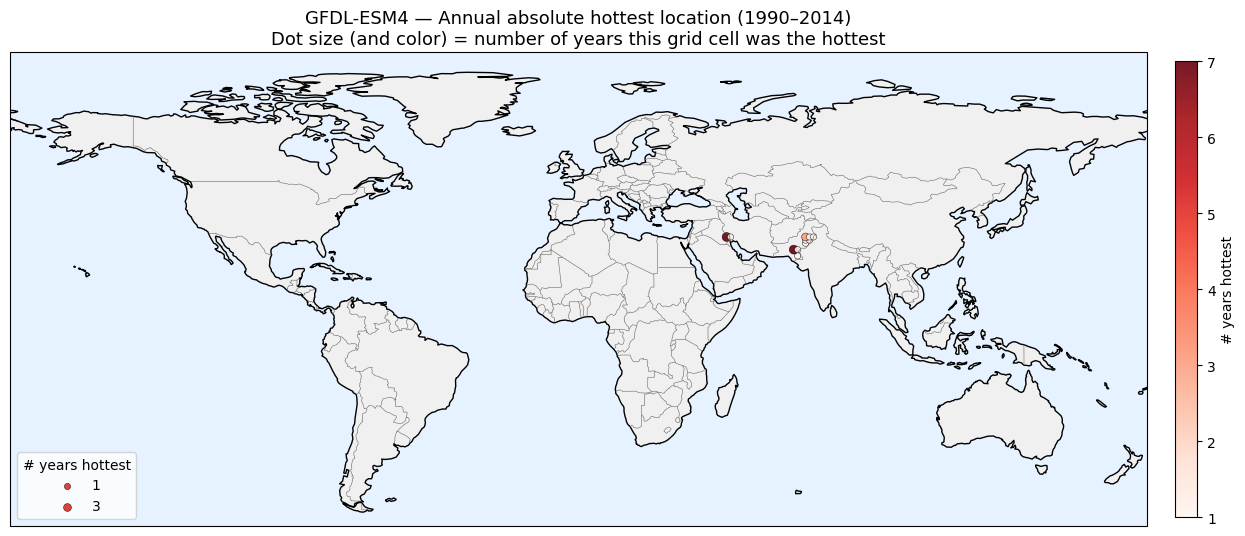

Saved figure: /content/drive/MyDrive/climate_work/output_figures_absmax_per_year/gfdl_absmax_hotspot_counts_1990_2014.png


In [ ]:
# ============================================================
# One-map hotspot view: size = how many years that cell was hottest
# Input: df with columns [year, lat, lon, tasmax_C]
# Output: single map + CSV of hotspot counts
# ============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# If df isn't in memory, load it:
# OUTDIR = "/content/drive/MyDrive/climate_work/output_figures_absmax_per_year"
# df     = pd.read_csv(f"{OUTDIR}/gfdl_absmax_per_year_1990_2014.csv")

OUTDIR  = "/content/drive/MyDrive/climate_work/output_figures_absmax_per_year"
os.makedirs(OUTDIR, exist_ok=True)
PNG_HS  = f"{OUTDIR}/gfdl_absmax_hotspot_counts_1990_2014.png"
CSV_HS  = f"{OUTDIR}/gfdl_absmax_hotspot_counts_1990_2014.csv"

LAT_MIN, LAT_MAX = -60, 90

# Optional: if you ever get nearly-identical coords, round them before grouping
# df["lat_r"] = df["lat"].round(5)
# df["lon_r"] = df["lon"].round(5)
# key_lat, key_lon = "lat_r", "lon_r"
key_lat, key_lon = "lat", "lon"

# Count how many years each location is the hottest
hotspots = (df.groupby([key_lat, key_lon], as_index=False)
              .agg(count=("year","size"),
                   max_temp=("tasmax_C","max"),
                   first_year=("year","min"),
                   last_year=("year","max")))

hotspots.to_csv(CSV_HS, index=False)
print("Saved hotspot counts CSV:", CSV_HS)
print(hotspots.sort_values("count", ascending=False).head())

# Size scaling: gentle nonlinearity so 1–10 years is visually distinct
def size_from_count(n):
    n = np.asarray(n, float)
    return 20 + 25*np.log10(np.maximum(n, 1.0))  # tweak constants to taste

# Color by count as well (optional); or use a single color
use_color_by_count = True
if use_color_by_count:
    cmap = mpl.cm.Reds
    norm = mpl.colors.Normalize(vmin=hotspots["count"].min(), vmax=hotspots["count"].max())
    colors = cmap(norm(hotspots["count"].values))
else:
    colors = "#d73027"

fig = plt.figure(figsize=(14, 6))
proj = ccrs.PlateCarree()
ax = plt.subplot(1,1,1, projection=proj)

ax.set_global()
ax.set_extent([-180, 180, LAT_MIN, LAT_MAX], crs=proj)
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0")
ax.add_feature(cfeature.OCEAN, facecolor="#e6f2ff")
ax.coastlines(); ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.4")

sc = ax.scatter(
    hotspots[key_lon].to_numpy(),
    hotspots[key_lat].to_numpy(),
    s=size_from_count(hotspots["count"].to_numpy()),
    c=(hotspots["count"].to_numpy() if use_color_by_count else colors),
    cmap=(cmap if use_color_by_count else None),
    norm=(norm if use_color_by_count else None),
    edgecolor="k", linewidth=0.35, alpha=0.9, transform=proj
)

# Legend for sizes (counts)
example_counts = np.unique(np.clip(hotspots["count"].to_numpy(), 1, None))
example_counts = np.array(sorted(set([1, 2, 3, 5, 10]) & set(example_counts) or [1, 2, 3, 5]))
handles = [plt.scatter([], [], s=size_from_count([c])[0], color="#d73027", alpha=0.9, edgecolor="k", linewidth=0.35)
           for c in example_counts]
ax.legend(handles, [str(int(c)) for c in example_counts],
          title="# years hottest", loc="lower left", frameon=True)

# Optional colorbar (if coloring by count)
if use_color_by_count:
    cbar = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("# years hottest")

ax.set_title("GFDL-ESM4 — Annual absolute hottest location (1990–2014)\n"
             "Dot size (and color) = number of years this grid cell was the hottest", fontsize=13)

plt.tight_layout()
plt.savefig(PNG_HS, dpi=300, bbox_inches="tight")
plt.show()
print("Saved figure:", PNG_HS)


/usr/local/lib/python3.12/dist-packages/dask/array/slicing.py:1006: PerformanceWarning: Increasing number of chunks by factor of 80
  p = blockwise(



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'



--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


/usr/local/lib/python3.12/dist-packages/dask/array/reductions.py:324: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


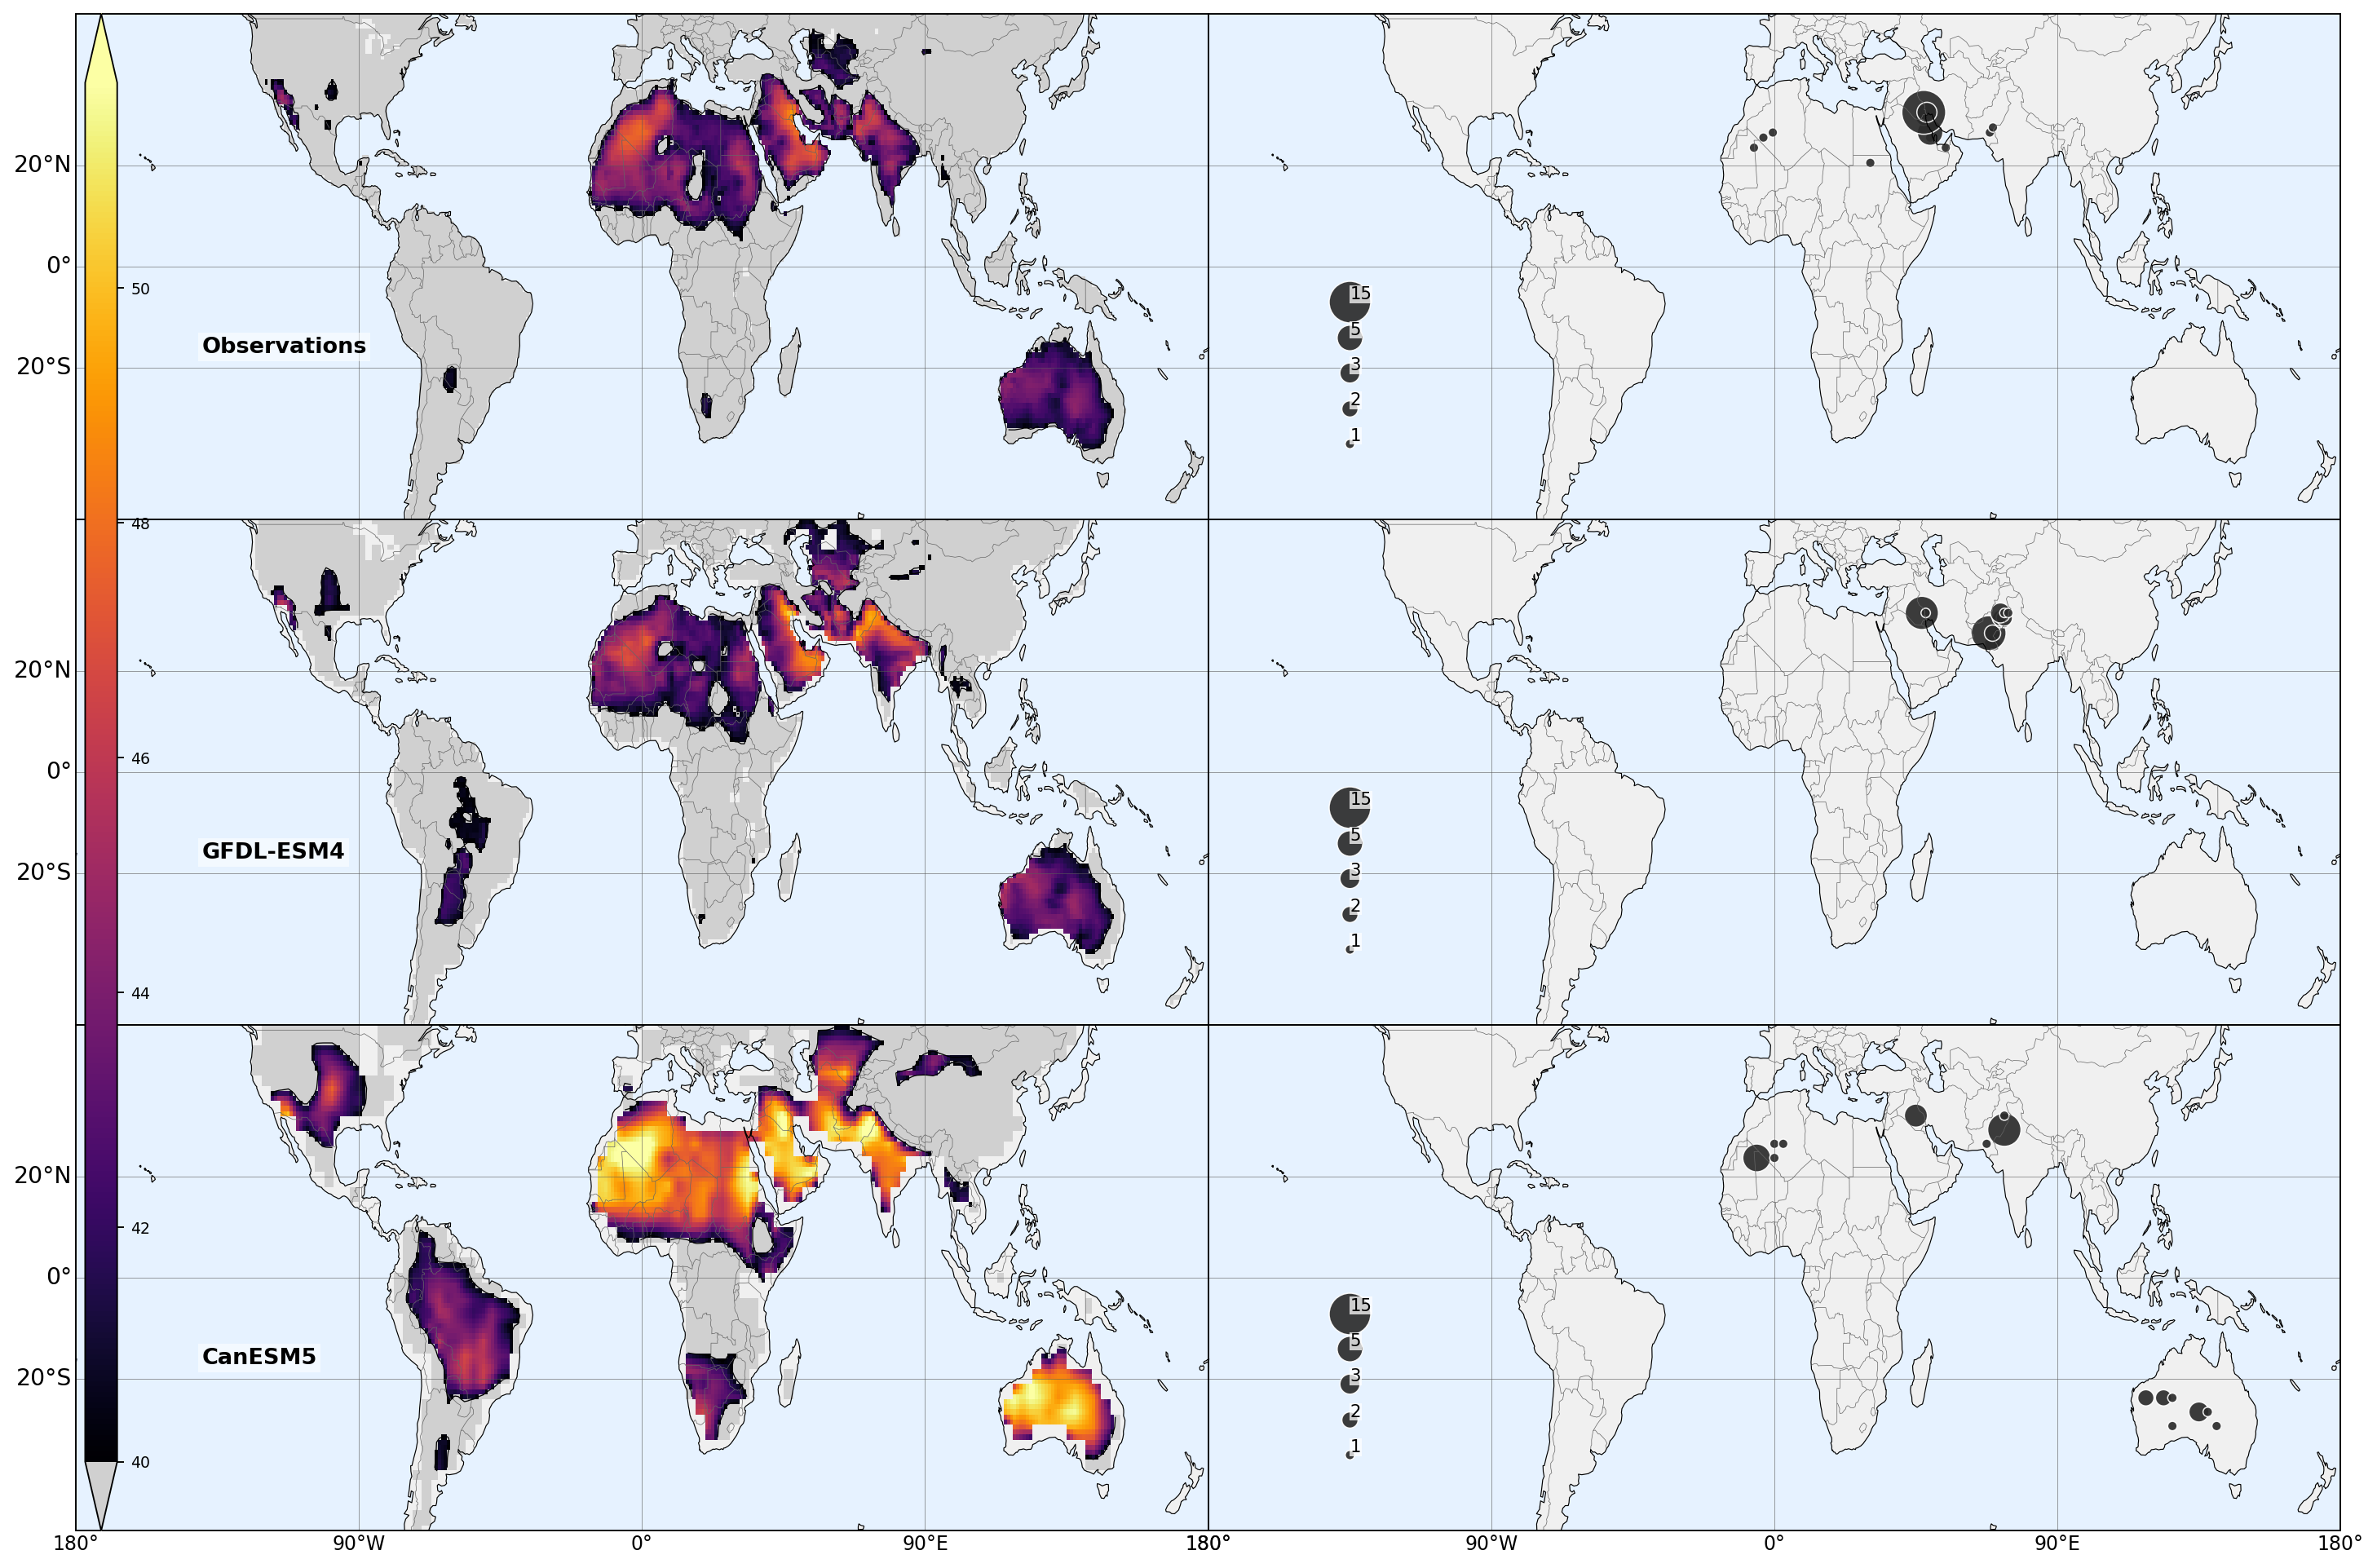

Saved: /content/drive/MyDrive/climate_work/output_figures_absmax_per_year/three_by_two_gapless_rows_cbar_LEFT_VERTICAL_ticksRIGHT_labelsOcean.png


In [1]:
# === 3×2 (Obs | GFDL-ESM4 | CanESM5; left=p99, right=hotspots) ===
# • Gapless layout, Cartopy PlateCarree
# • LEFT column: p99 maps (inferno); RIGHT column: hotspot counts (size-only)
# • VERTICAL colorbar placed far left; ticks on RIGHT; no colorbar label
# • Panel labels only on LEFT column, placed by lon/lat over South Pacific

import os, shutil
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
import intake

# ----------------- SETTINGS -----------------
WORKDIR = "/content/drive/MyDrive/climate_work"
BERKELEY_FILES = [
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_1980.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_1990.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_2000.nc",
    f"{WORKDIR}/Complete_TMAX_Daily_LatLong1_2010.nc",
]

T0, T1 = "1980-01-01", "2014-12-31"
LAT_MIN, LAT_MAX = -50, 50
THRESH_C = 40.0

BEST_MODEL  = "GFDL-ESM4"
WORST_MODEL = "CanESM5"

FIGSIZE = (16.5, 12.0)
mpl.rcParams["figure.dpi"] = 170
mpl.rcParams["savefig.dpi"] = 300
OUTDIR = f"{WORKDIR}/output_figures_absmax_per_year"
os.makedirs(OUTDIR, exist_ok=True)
OUTPNG = f"{OUTDIR}/three_by_two_gapless_rows_cbar_LEFT_VERTICAL_ticksRIGHT_labelsOcean.png"

CMAP_P99 = "inferno"

# Hotspot dots
DOT_COLOR = "#2b2b2b"; DOT_EDGE="white"; DOT_EW=0.65; DOT_ALPHA=0.92
S_MIN, S_MAX = 24, 520; GAMMA = 0.85

# ----------------- HELPERS -----------------
def normalize_coords(ds):
    if "latitude"  in ds.coords: ds = ds.rename({"latitude": "lat"})
    if "longitude" in ds.coords: ds = ds.rename({"longitude":"lon"})
    if "lon" in ds.coords:
        lon = xr.where(ds["lon"] > 180, ds["lon"] - 360, ds["lon"])
        ds  = ds.assign_coords(lon=lon).sortby("lon")
    if "lat" in ds.coords and ds.lat.size > 1 and float(ds.lat[0]) > float(ds.lat[-1]):
        ds = ds.sortby("lat")
    return ds

def open_one_localcopy(path):
    p = f"/content/{os.path.basename(path)}"
    if not os.path.exists(p) or os.path.getsize(p) != os.path.getsize(path):
        shutil.copy2(path, p)
    last = None
    for eng in ["h5netcdf","netcdf4","scipy"]:
        try:
            kw = dict(chunks={"time":90,"lat":180,"lon":180})
            if eng=="h5netcdf":
                return xr.open_dataset(p, engine=eng, backend_kwargs={"invalid_netcdf":True}, **kw)
            elif eng=="netcdf4":
                return xr.open_dataset(p, engine=eng, **kw)
            else:
                return xr.open_dataset(p, engine=eng)
        except Exception as e:
            last = e
    raise last

def ensure_datetime_time(ds):
    if "time" in ds.dims and "time" in ds.coords:
        return ds
    n = ds.sizes["time"]
    t = pd.date_range(T0, periods=n, freq="D")
    return ds.assign_coords(time=("time", t))

def hottest_points_df(da_time_lat_lon):
    annmax  = da_time_lat_lon.groupby("time.year").max("time")
    stacked = annmax.stack(space=("lat","lon")).fillna(-np.inf)
    imax    = np.asarray(stacked.argmax("space").values).ravel()
    vals    = np.asarray(stacked.max("space").values).ravel()
    nlat, nlon = int(annmax.sizes["lat"]), int(annmax.sizes["lon"])
    ilat, ilon = np.unravel_index(imax, (nlat, nlon))
    years = np.asarray(annmax["year"].values, dtype=int).ravel()
    latv  = np.asarray(annmax["lat"].values,  dtype=float)
    lonv  = np.asarray(annmax["lon"].values,  dtype=float)
    lats  = latv[ilat].astype(float).ravel()
    lons  = lonv[ilon].astype(float).ravel()
    vals  = vals.astype(float).ravel()
    m = min(len(years), len(lats), len(lons), len(vals))
    return pd.DataFrame({"year":years[:m], "lat":lats[:m], "lon":lons[:m], "value":vals[:m]}).sort_values("year")

def aggregate_counts(df):
    hs = (df.groupby(["lat","lon"], as_index=False)
            .agg(count=("year","size"),
                 max_value=("value","max"),
                 first_year=("year","min"),
                 last_year=("year","max")))
    hs["count"] = hs["count"].astype(int)
    return hs

def shared_size_map(counts, cmin, cmax, smin=S_MIN, smax=S_MAX, gamma=GAMMA):
    counts = np.asarray(counts, float)
    if cmax <= cmin:
        return np.full_like(counts, (smin+smax)/2)
    x = (counts - cmin) / (cmax - cmin)
    x = np.clip(x, 0, 1) ** gamma
    return smin + x * (smax - smin)

def plot_base(ax):
    ax.set_extent([-180, 180, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    ax.set_aspect('auto')
    ax.set_facecolor("#e6f2ff")
    ax.add_feature(cfeature.LAND,  facecolor="#f0f0f0")
    ax.add_feature(cfeature.OCEAN, facecolor="#e6f2ff")
    ax.coastlines(resolution="110m", linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.4")
    for s in ["left","right","bottom","top"]:
        ax.spines[s].set_linewidth(0.55)

def to_latlon2d(da):
    if "quantile" in da.dims:
        da = da.isel(quantile=0)
    for d in list(da.dims):
        if d not in ("lat","lon"):
            da = da.isel({d:0}) if da.sizes[d]==1 else da.mean(d)
    rn = {}
    if "latitude"  in da.dims: rn["latitude"]  = "lat"
    if "longitude" in da.dims: rn["longitude"] = "lon"
    if rn: da = da.rename(rn)
    return da.transpose("lat","lon")

def plot_p99_field(ax, p99_da, vmin=THRESH_C, vmax=None, cmap=CMAP_P99):
    plot_base(ax)
    p99_2d = to_latlon2d(p99_da).sel(lat=slice(LAT_MIN, LAT_MAX))
    if vmax is None:
        vmax = float(np.nanpercentile(p99_2d, 99))
        vmax = max(vmax, THRESH_C + 5)
    cmap_obj = mpl.colormaps.get_cmap(cmap).copy()
    cmap_obj.set_under("#d0d0d0")
    im = ax.pcolormesh(p99_2d["lon"], p99_2d["lat"], p99_2d,
                       transform=ccrs.PlateCarree(), cmap=cmap_obj,
                       vmin=vmin, vmax=vmax, shading="nearest")
    ax.contour(p99_2d["lon"], p99_2d["lat"], p99_2d, levels=[THRESH_C],
               colors="k", linewidths=0.55, transform=ccrs.PlateCarree())
    return im

def plot_hotspots_sizeonly(ax, hs, cmin, cmax):
    plot_base(ax)
    if hs is not None and len(hs):
        counts = hs["count"].to_numpy().astype(float)
        sizes  = shared_size_map(counts, cmin, cmax)
        ax.scatter(hs["lon"].to_numpy(), hs["lat"].to_numpy(),
                   s=sizes, c=DOT_COLOR, alpha=DOT_ALPHA,
                   edgecolor=DOT_EDGE, linewidth=DOT_EW,
                   transform=ccrs.PlateCarree())
    else:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", fontsize=10, color="0.4")

def interp_mask_to(landmask_ref, lat, lon, method="nearest"):
    lm = landmask_ref
    if "latitude"  in lm.coords: lm = lm.rename({"latitude":"lat"})
    if "longitude" in lm.coords: lm = lm.rename({"longitude":"lon"})
    if float(lm.lon.max()) > 180:
        lm = lm.assign_coords(lon=xr.where(lm.lon > 180, lm.lon - 360, lm.lon)).sortby("lon")
    return lm.interp(lat=lat, lon=lon, method=method)

# --- Left-panel label placed by geographic coords (safe over ocean) ---
def add_inpanel_label_ocean(ax, text, lon=-140, lat=-18):
    ax.text(lon, lat, text,
            transform=ccrs.PlateCarree(),
            ha="left", va="bottom",
            fontsize=11.5, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=1.8),
            zorder=5)

# vertical size legend over ocean (shared scale)
def add_size_legend_vertical(ax, cmin, cmax, lon=-135, lat_start=-35, dlat=7, max_marks=5):
    if cmax < cmin: cmin, cmax = cmax, cmin
    candidates = np.array([1, 2, 3, 5, 10, 15, 20, 25, 30])
    ticks = [int(t) for t in candidates if cmin <= t <= cmax] or [int(cmin), int(cmax)]
    ticks = sorted(set(ticks))
    if len(ticks) > max_marks:
        idx = np.linspace(0, len(ticks)-1, num=max_marks, dtype=int)
        ticks = [ticks[i] for i in idx]
    for i, c in enumerate(ticks):
        s = shared_size_map([c], cmin, cmax)[0]
        y = lat_start + i*dlat
        ax.scatter(lon, y, s=s, c=DOT_COLOR, alpha=DOT_ALPHA,
                   edgecolor=DOT_EDGE, linewidth=DOT_EW,
                   transform=ccrs.PlateCarree(), zorder=3)
        ax.text(lon, y + 1.5, f"{c}", ha="left", va="center",
                transform=ccrs.PlateCarree(), fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.4),
                zorder=4)

def add_geo_labels(ax, show_left=False, show_bottom=False):
    meridians = [-180, -90, 0, 90, 180]; parallels = [-20, 0, 20]
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      xlocs=meridians, ylocs=parallels,
                      linewidth=0.4, color="0.35", alpha=0.6, linestyle="-", zorder=6)
    gl.rotate_labels = False
    gl.xformatter = LongitudeFormatter(number_format=".0f", degree_symbol="°")
    gl.yformatter = LatitudeFormatter(number_format=".0f", degree_symbol="°")
    gl.top_labels = False; gl.right_labels = False
    gl.left_labels = bool(show_left); gl.bottom_labels = bool(show_bottom)
    gl.xlabel_style = dict(size=10, weight="normal"); gl.ylabel_style = dict(size=12, weight="normal")
    gl.xpadding = 2; gl.ypadding = 2
    import matplotlib.patheffects as pe
    def _apply_halo(objs):
        try:
            for t in objs:
                t.set_path_effects([pe.Stroke(linewidth=2.2, foreground="white"), pe.Normal()])
        except TypeError:
            for txts in objs.values():
                if isinstance(txts, list):
                    for t in txts:
                        t.set_path_effects([pe.Stroke(linewidth=2.2, foreground="white"), pe.Normal()])
                else:
                    txts.set_path_effects([pe.Stroke(linewidth=2.2, foreground="white"), pe.Normal()])
    _apply_halo(getattr(gl, "label_artists", []))

# ----------------- DATA PREP -----------------
opened = [normalize_coords(open_one_localcopy(f)) for f in BERKELEY_FILES]
dsb = xr.concat(opened, dim="time", data_vars="minimal", coords="minimal", compat="override")

# decode_times deprecation-safe
try:
    from xarray.coders import CFDatetimeCoder
except Exception:
    try:
        from xarray.coding.times import CFDatetimeCoder
    except Exception:
        CFDatetimeCoder = None

if CFDatetimeCoder is not None:
    time_coder = CFDatetimeCoder(use_cftime=True)
    dsb = xr.decode_cf(dsb, decode_times=time_coder, mask_and_scale=True).sortby("time")
else:
    dsb = xr.decode_cf(dsb, use_cftime=True, mask_and_scale=True).sortby("time")

dsb = ensure_datetime_time(dsb)

anom  = dsb["temperature"]
clim  = dsb["climatology"]
doy   = dsb["day_of_year"]
lmask_ref = dsb.get("land_mask")
if lmask_ref is None:
    lmask_ref = xr.where(~xr.ufuncs.isnan(clim.isel(time=0) if "time" in clim.dims else clim.isel(dayofyear=0)),
                         1.0, 0.0)

# harmonize clim axis -> dayofyear
if "day_number" in clim.dims: clim = clim.rename({"day_number":"dayofyear"})
elif "day_of_year" in clim.dims: clim = clim.rename({"day_of_year":"dayofyear"})
elif "time" in clim.dims and clim.sizes["time"] in (365, 366): clim = clim.rename({"time":"dayofyear"})

# integer DOY indexer
doy_i  = xr.where(doy > 365, 365, doy).astype("int32")
start  = int(np.nanmin(clim["dayofyear"].values))
indexer = xr.where(doy_i > 365, 364, doy_i - 1) if start == 0 else doy_i
clim_sel = clim.sel(dayofyear=indexer)

# absolute daily max, land-only, time slice
Tmax_abs = (anom + clim_sel).rename("Tmax_abs").where(lmask_ref > 0.5).sel(time=slice(T0, T1))

# Observation p99
p99_obs_native = Tmax_abs.chunk({'time': -1, 'lat': 180, 'lon': 180}).quantile(0.99, dim="time")
p99_obs        = p99_obs_native

# Models (tasmax)
def load_model_tasmax(source_id):
    col = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
    cat = col.search(source_id=source_id, experiment_id="historical", table_id="day", variable_id="tasmax")
    dsets = cat.to_dataset_dict(zarr_kwargs={"consolidated": True, "use_cftime": True},
                                storage_options={"token": "anon"})
    ds = normalize_coords(list(dsets.values())[0])
    tas = ds["tasmax"].sel(time=slice(T0, T1))
    u = str(tas.attrs.get("units","")).lower()
    if u in ["k","kelvin"] or float(tas.isel(time=0).max()) > 200:
        tas = tas - 273.15; tas.attrs["units"] = "degree_Celsius"
    return tas

tas_best  = load_model_tasmax(BEST_MODEL)
tas_worst = load_model_tasmax(WORST_MODEL)

# same land mask
mask_best  = interp_mask_to(lmask_ref, lat=tas_best.lat,  lon=tas_best.lon,  method="nearest")
mask_worst = interp_mask_to(lmask_ref, lat=tas_worst.lat, lon=tas_worst.lon, method="nearest")
tas_best_land  = tas_best.where(mask_best  > 0.5)
tas_worst_land = tas_worst.where(mask_worst > 0.5)

# p99 and regrid to Berkeley grid
def regrid_to_berkeley_bilinear(p99_native_2d, target_lat, target_lon):
    da = to_latlon2d(p99_native_2d)
    if float(da.lon.max()) > 180:
        da = da.assign_coords(lon=xr.where(da.lon > 180, da.lon - 360, da.lon)).sortby("lon")
    return da.interp(lat=target_lat, lon=target_lon, method="linear")

p99_best_native  = tas_best_land.chunk({'time': -1, 'lat': 180, 'lon': 180}).quantile(0.99, dim="time")
p99_worst_native = tas_worst_land.chunk({'time': -1, 'lat': 180, 'lon': 180}).quantile(0.99, dim="time")

p99_best  = regrid_to_berkeley_bilinear(p99_best_native,  dsb.lat, dsb.lon)
p99_worst = regrid_to_berkeley_bilinear(p99_worst_native, dsb.lat, dsb.lon)

# Hotspots
df_obs  = hottest_points_df(Tmax_abs);  df_obs  = df_obs[(df_obs["lat"] >= LAT_MIN) & (df_obs["lat"] <= LAT_MAX)]
hs_obs  = aggregate_counts(df_obs)
df_best = hottest_points_df(tas_best_land); df_best = df_best[(df_best["lat"] >= LAT_MIN) & (df_best["lat"] <= LAT_MAX)]
hs_best = aggregate_counts(df_best)
df_worst = hottest_points_df(tas_worst_land); df_worst = df_worst[(df_worst["lat"] >= LAT_MIN) & (df_worst["lat"] <= LAT_MAX)]
hs_worst = aggregate_counts(df_worst)

# ----------------- PLOTTING -----------------
fig = plt.figure(figsize=FIGSIZE)
proj = ccrs.PlateCarree()

def make_axes_grid(fig, nrows=3, ncols=2,
                   left=0.006, right=0.996, top=0.992, bottom=0.080,
                   row_gap=0.0, col_gap=0.0001):
    width, height = right-left, top-bottom
    cell_w = (width - (ncols-1)*col_gap) / ncols
    cell_h = (height - (nrows-1)*row_gap) / nrows
    axes = []
    for r in range(nrows):
        row = []
        y0 = top - (r+1)*cell_h - r*row_gap
        for c in range(ncols):
            x0 = left + c*(cell_w + col_gap)
            ax = fig.add_axes([x0, y0, cell_w, cell_h], projection=proj)
            row.append(ax)
        axes.append(row)
    return axes, dict(cell_w=cell_w, cell_h=cell_h, left=left, right=right,
                      top=top, bottom=bottom, width=width, height=height)

(axes, layout) = make_axes_grid(fig, 3, 2, left=0.006, right=0.996, top=0.992, bottom=0.080, row_gap=0.0, col_gap=0.0001)

ax_obs_p99,  ax_obs_hot  = axes[0]
ax_gfdl_p99, ax_gfdl_hot = axes[1]
ax_can_p99,  ax_can_hot  = axes[2]

def robust_p99_vmax(da):
    d2 = to_latlon2d(da).sel(lat=slice(LAT_MIN, LAT_MAX))
    vmax = float(np.nanpercentile(d2, 99))
    return max(vmax, THRESH_C + 5)

vmax_all = max(robust_p99_vmax(p99_obs), robust_p99_vmax(p99_best), robust_p99_vmax(p99_worst))

im_obs  = plot_p99_field(ax_obs_p99,  p99_obs,  vmin=THRESH_C, vmax=vmax_all, cmap=CMAP_P99)
im_gfdl = plot_p99_field(ax_gfdl_p99, p99_best, vmin=THRESH_C, vmax=vmax_all, cmap=CMAP_P99)
im_cane = plot_p99_field(ax_can_p99,  p99_worst, vmin=THRESH_C, vmax=vmax_all, cmap=CMAP_P99)

all_counts = []
for hs in (hs_obs, hs_best, hs_worst):
    if len(hs): all_counts.extend(hs["count"].to_numpy().tolist())
cmin = max(1, int(np.min(all_counts))) if all_counts else 1
cmax = int(np.max(all_counts))         if all_counts else 1

plot_hotspots_sizeonly(ax_obs_hot,  hs_obs,  cmin, cmax)
plot_hotspots_sizeonly(ax_gfdl_hot, hs_best, cmin, cmax)
plot_hotspots_sizeonly(ax_can_hot,  hs_worst, cmin, cmax)

# LEFT-column labels placed by lon/lat (well away from the colorbar)
add_inpanel_label_ocean(ax_obs_p99,  "Observations", lon=-140, lat=-18)
add_inpanel_label_ocean(ax_gfdl_p99, "GFDL-ESM4",    lon=-140, lat=-18)
add_inpanel_label_ocean(ax_can_p99,  "CanESM5",      lon=-140, lat=-18)

# Vertical dot-size legends on RIGHT panels
if len(hs_obs):   add_size_legend_vertical(ax_obs_hot,  cmin, cmax, lon=-135, lat_start=-35)
if len(hs_best):  add_size_legend_vertical(ax_gfdl_hot, cmin, cmax, lon=-135, lat_start=-35)
if len(hs_worst): add_size_legend_vertical(ax_can_hot,  cmin, cmax, lon=-135, lat_start=-35)

# Geo labels
add_geo_labels(ax_obs_p99,  show_left=True,  show_bottom=False)
add_geo_labels(ax_gfdl_p99, show_left=True,  show_bottom=False)
add_geo_labels(ax_can_p99,  show_left=True,  show_bottom=True)
add_geo_labels(ax_obs_hot,  show_left=False, show_bottom=False)
add_geo_labels(ax_gfdl_hot, show_left=False, show_bottom=False)
add_geo_labels(ax_can_hot,  show_left=False, show_bottom=True)

# ---- VERTICAL colorbar (same position you liked), ticks on RIGHT, NO label ----
CBAR_WIDTH  = 0.014
CBAR_PAD_X  = 0.060   # keep as-is (you liked this)
CBAR_MIN_X  = 0.010
cbar_x = max(CBAR_MIN_X, layout["left"] - CBAR_PAD_X - CBAR_WIDTH)
cbar_y = layout["bottom"]; cbar_h = layout["height"]
cax_left_vert = fig.add_axes([cbar_x, cbar_y, CBAR_WIDTH, cbar_h])
cbar = fig.colorbar(im_obs, cax=cax_left_vert, orientation="vertical", extend="both")

cbar.ax.yaxis.set_ticks_position('right')
cbar.ax.tick_params(labelright=True, right=True, labelleft=False, left=False, labelsize=8)
cbar.set_label("")   # caption will explain the variable/units

# save
plt.savefig(OUTPNG, bbox_inches=None)
plt.show()
print("Saved:", OUTPNG)
